# 03 — Customer value, repeat behavior and acquisition cohorts
**Business question:** How dependent is growth on first-time buyers, and what credible retention hypotheses follow?

**Contents:** acquisition versus returning orders; cohort retention; 90-day second purchase; RFM; action matrix. These analyses describe the observed history, not lifetime loyalty or churn.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
pd.set_option('display.max_columns', 18)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
def table(name): return pd.read_csv(ROOT / 'output' / (name + '.csv'))
def chart(name): display(Image(filename=str(ROOT / 'images' / name), width=950))
def decision(evidence, interpretation, action, kpi):
    display(Markdown(f'**What the data shows:** {evidence}\n\n**Business interpretation:** {interpretation}\n\n**Recommended action:** {action}\n\n**KPI to monitor:** {kpi}'))

In [2]:
from src.pipeline import load_model
from src.feature_engineering import customer_features,cohorts,second_purchase
model=load_model(ROOT)
customers,segments=customer_features(model)
cohort=cohorts(model['FactOrders'])
second=second_purchase(model['FactOrders'])

## Acquisition and repeat contribution
First purchases establish observed acquisition cohorts. A subsequent order is returning even if it occurs in the same month; monthly new and returning customer counts can overlap. Separate returning-order GMV from all GMV of customers who eventually repeat.

In [3]:
display(table('acquisition').tail(14))
k=table('kpis').set_index('metric').value
decision(f"Repeat customers are {k['Repeat customer rate']:.2%}; subsequent-order GMV is {k['Returning order GMV share']:.2%}; all GMV from repeat customers is {k['Repeat customer lifetime GMV share']:.2%}.",
         'First observed purchases dominate this marketplace sample; repeat behavior has limited variation.',
         'Prioritize a measured second-purchase test while accounting for customer exposure time.',
         '90-day second-purchase rate and incremental GMV/customer.')

,purchase_month,order_type,customers,orders,gmv,aov,monthly_gmv_share
30,2018-02,New customer order,6288,6288,"797,353.8300",126.8056,0.9648
31,2018-02,Returning customer order,252,267,"29,083.3000",108.9262,0.0352
32,2018-03,New customer order,6774,6774,"926,565.7500",136.7827,0.9719
33,2018-03,Returning customer order,225,229,"26,790.5000",116.9891,0.0281
34,2018-04,New customer order,6582,6582,"945,946.3600",143.7172,0.9717
35,2018-04,Returning customer order,211,216,"27,587.7300",127.7210,0.0283
36,2018-05,New customer order,6506,6506,"944,255.3800",145.1361,0.9659
37,2018-05,Returning customer order,235,243,"33,289.3100",136.9930,0.0341
38,2018-06,New customer order,5878,5878,"827,275.6800",140.7410,0.9664
39,2018-06,Returning customer order,215,221,"28,802.1800",130.3266,0.0336


**What the data shows:** Repeat customers are 3.00%; subsequent-order GMV is 2.90%; all GMV from repeat customers is 5.51%.

**Business interpretation:** First observed purchases dominate this marketplace sample; repeat behavior has limited variation.

**Recommended action:** Prioritize a measured second-purchase test while accounting for customer exposure time.

**KPI to monitor:** 90-day second-purchase rate and incremental GMV/customer.

## Cohort activity retention
The denominator is unique acquired customers. Month 0 is 100% by construction. Subsequent cells measure activity in that month, not cumulative repeat conversion. Future or possibly incomplete periods remain missing; observable inactivity is zero.

age_month,0,1,2,3,4,5,6,7,8,...,15,16,17,18,19,20,21,22,23
cohort_month,,,,,,,,,,,,,,,,,,,
2016-09,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN
2016-10,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0038,0.0000,0.0000,...,0.0038,0.0000,0.0038,0.0000,0.0076,0.0076,0.0000,NaN,NaN
2016-12,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN
2017-01,1.0000,0.0028,0.0028,0.0014,0.0042,0.0014,0.0042,0.0014,0.0014,...,0.0014,0.0028,0.0042,0.0000,NaN,NaN,NaN,NaN,NaN
2017-02,1.0000,0.0018,0.0031,0.0012,0.0043,0.0012,0.0025,0.0018,0.0012,...,0.0006,0.0006,0.0018,NaN,NaN,NaN,NaN,NaN,NaN
2017-03,1.0000,0.0044,0.0036,0.0040,0.0036,0.0016,0.0016,0.0032,0.0032,...,0.0024,0.0008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-04,1.0000,0.0062,0.0022,0.0018,0.0027,0.0027,0.0035,0.0031,0.0031,...,0.0009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-05,1.0000,0.0046,0.0046,0.0029,0.0029,0.0032,0.0041,0.0014,0.0026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-06,1.0000,0.0049,0.0040,0.0043,0.0030,0.0040,0.0036,0.0023,0.0013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,cohort_month,cohort_size
0,2016-09,1
24,2016-10,262
47,2016-12,1
68,2017-01,717
88,2017-02,1628
107,2017-03,2503
125,2017-04,2256
142,2017-05,3451
158,2017-06,3037
173,2017-07,3752


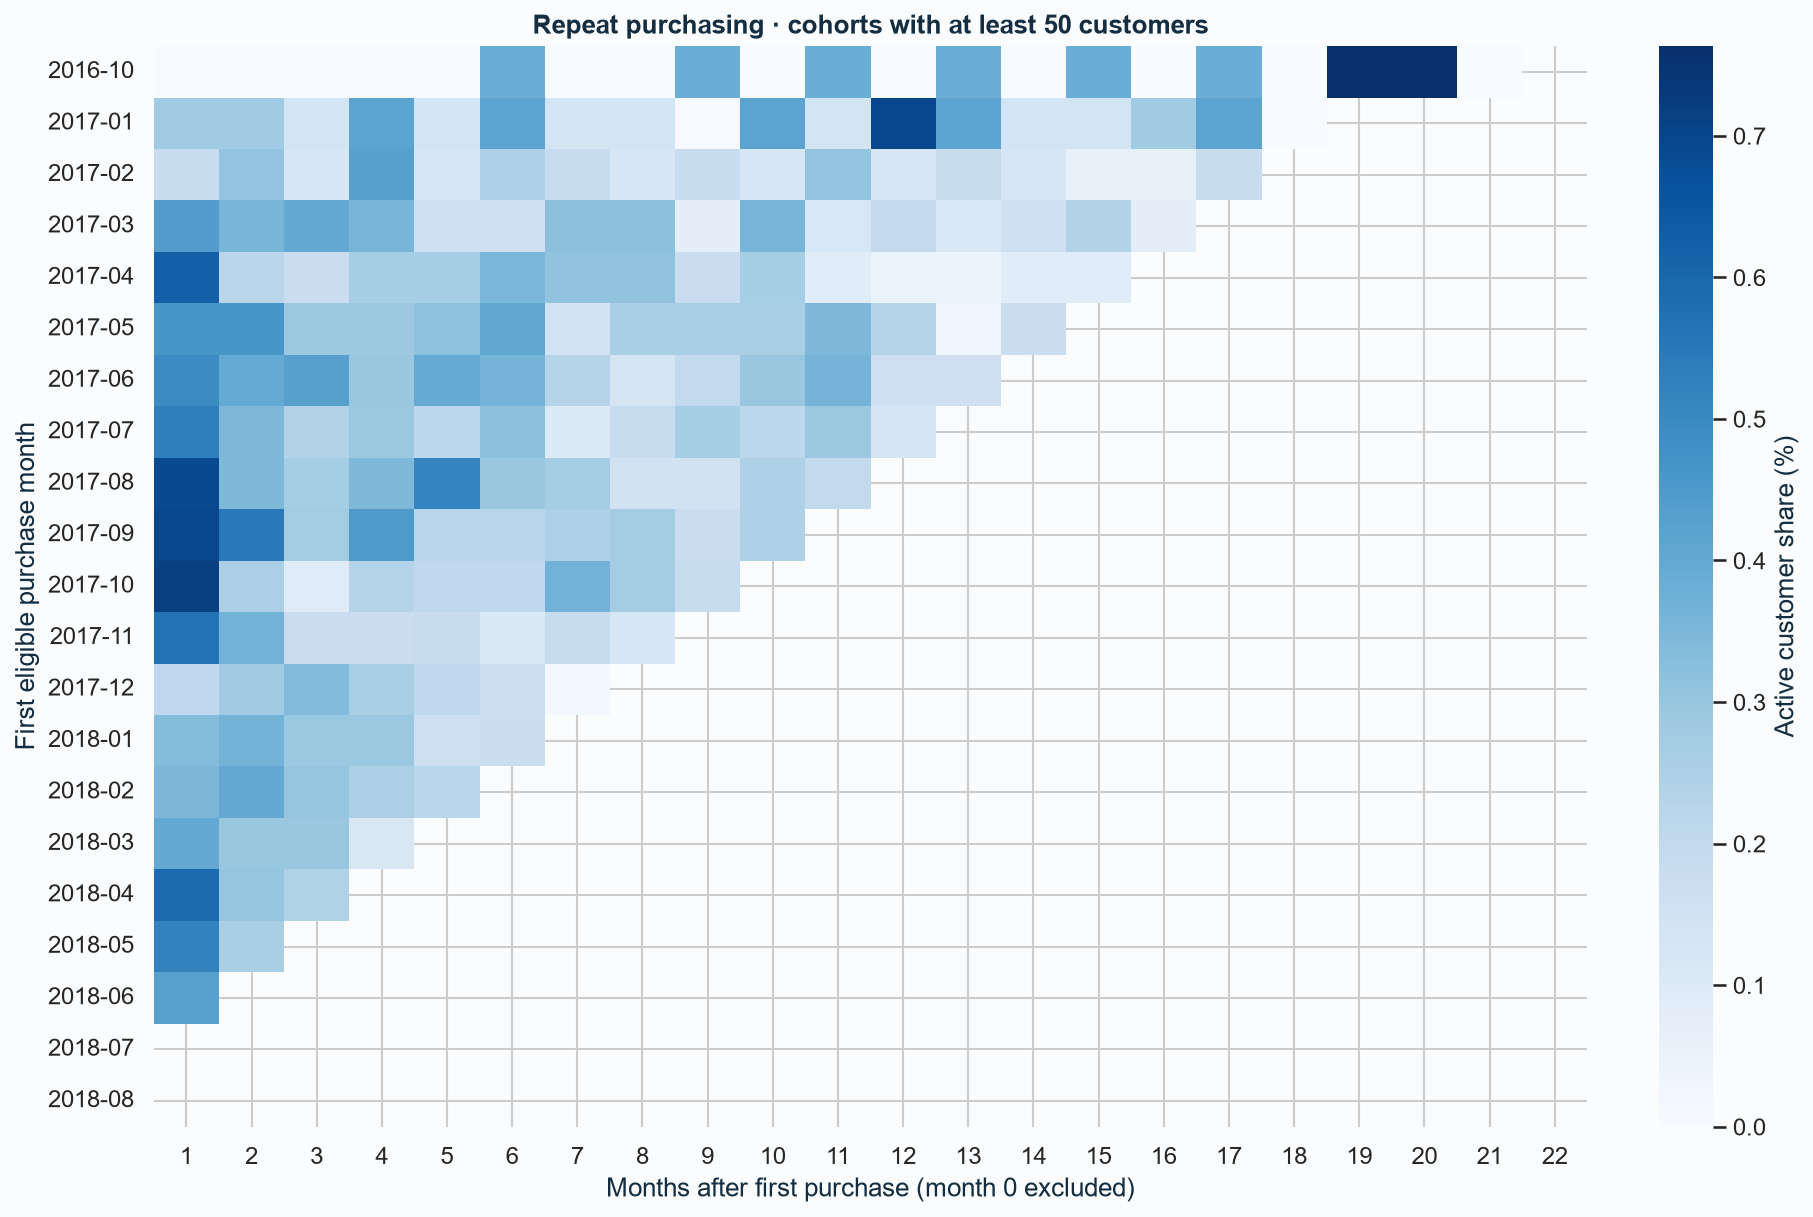

**What the data shows:** The heatmap separates observed zeros from unavailable cohort periods.

**Business interpretation:** Newer cohorts have less follow-up; raw lifetime repeat comparisons are biased.

**Recommended action:** Compare cohorts at equal age and report cohort sizes beside rates.

**KPI to monitor:** Month-age active-customer share with observable denominators.

In [4]:
display(cohort.pivot(index='cohort_month',columns='age_month',values='retention_rate'))
display(cohort[['cohort_month','cohort_size']].drop_duplicates())
chart('retention_cohort.png')
decision('The heatmap separates observed zeros from unavailable cohort periods.',
         'Newer cohorts have less follow-up; raw lifetime repeat comparisons are biased.',
         'Compare cohorts at equal age and report cohort sizes beside rates.',
         'Month-age active-customer share with observable denominators.')

## Equal 90-day follow-up
Only customers whose first purchase occurs at least 90 days before the last eligible observed purchase enter the denominator. This cutoff is conservative; the public files do not certify a formal extraction timestamp.

In [5]:
display(second)
rate=second.second_buyers.sum()/second.eligible_customers.sum()
decision(f"{second.eligible_customers.sum():,} customers have 90-day follow-up; {rate:.2%} bought again within 90 days.",
         'This supports a second-purchase baseline without inventing a churn outcome.',
         'Use 90-day conversion as a preregistered outcome for an opt-in lifecycle test.',
         'Incremental second-purchase rate versus a control and incentive cost.')

,first_month,eligible_customers,second_buyers,second_purchase_rate,horizon_days
0,2016-09,1,0,0.0000,90
1,2016-10,262,3,0.0115,90
2,2016-12,1,1,1.0000,90
3,2017-01,717,26,0.0363,90
4,2017-02,1628,28,0.0172,90
5,2017-03,2503,62,0.0248,90
6,2017-04,2256,48,0.0213,90
7,2017-05,3451,98,0.0284,90
8,2017-06,3037,86,0.0283,90
9,2017-07,3752,97,0.0259,90


**What the data shows:** 75,320 customers have 90-day follow-up; 2.28% bought again within 90 days.

**Business interpretation:** This supports a second-purchase baseline without inventing a churn outcome.

**Recommended action:** Use 90-day conversion as a preregistered outcome for an opt-in lifecycle test.

**KPI to monitor:** Incremental second-purchase rate versus a control and incentive cost.

## RFM with tied frequency handled explicitly
Snapshot is the last eligible purchase date + one day. Recency and monetary scores preserve ties. Frequency bins are 1, 2, 3 and 4+ orders, so one-time customers are not artificially separated by quantiles. Labels such as previously high value/inactive describe observed recency, not contractual churn.

,recency,frequency,monetary,aov
count,"93,358.0000","93,358.0000","93,358.0000","93,358.0000"
mean,238.4789,1.0334,141.6215,137.5083
std,152.5951,0.2091,215.6940,209.8603
min,1.0000,1.0000,0.8500,0.8500
25%,115.0000,1.0000,47.6500,46.0000
50%,219.0000,1.0000,89.7300,86.9900
75%,347.0000,1.0000,154.7375,149.9000
90%,466.0000,1.0000,279.9900,269.0000
99%,576.0000,2.0000,"1,004.9900",997.8860
max,714.0000,15.0000,"13,440.0000","13,440.0000"


,segment,customers,gmv,orders,average_recency,average_frequency,average_monetary,aov,customer_share,gmv_share
0,Champions,1310,"393,299.5000",2834,113.3405,2.1634,300.2286,138.7789,0.0140,0.0297
1,High value,10727,"3,789,738.3200",10727,112.3120,1.0000,353.2897,353.2897,0.1149,0.2866
2,Low recent engagement,34486,"2,398,025.7000",34486,364.4500,1.0000,69.5362,69.5362,0.3694,0.1814
3,Potential second purchase,17320,"1,235,774.0100",17320,166.5912,1.0000,71.3495,71.3495,0.1855,0.0935
4,Previously high value / inactive,11647,"4,126,009.1400",12431,365.4411,1.0673,354.2551,331.9129,0.1248,0.3121
5,Recent,17090,"1,211,582.4800",17090,57.2091,1.0000,70.8942,70.8942,0.1831,0.0916
6,Repeat buyers,778,"67,068.9600",1590,286.4859,2.0437,86.2069,42.1817,0.0083,0.0051


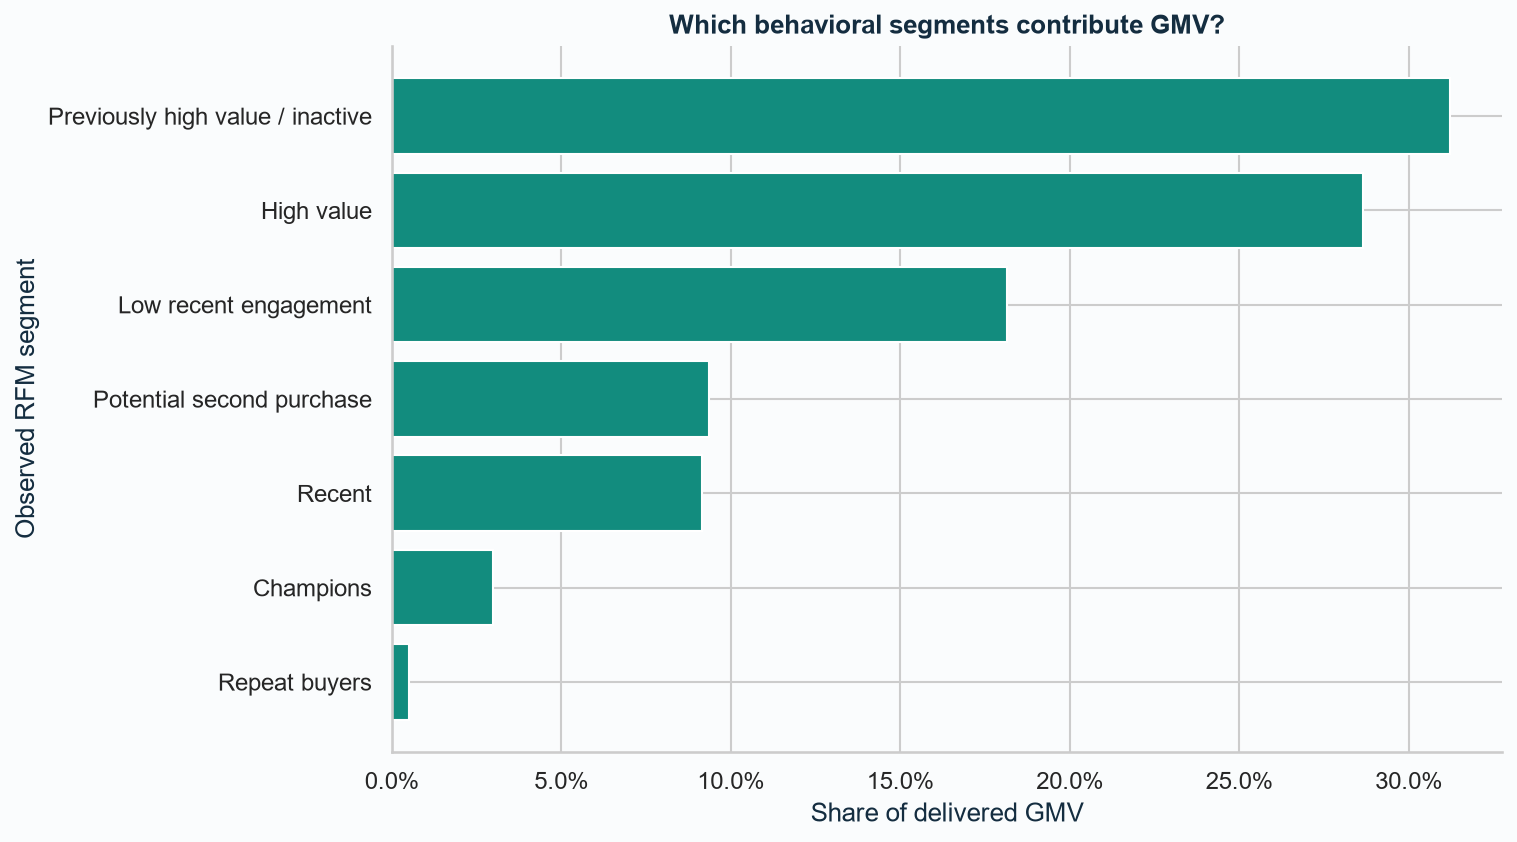

**What the data shows:** 97.0% of observed customers have exactly one eligible order.

**Business interpretation:** Traditional RFM frequency scoring has little differentiation; recency and monetary value carry most variation.

**Recommended action:** Use simple interpretable rules and compare any clustering against this baseline.

**KPI to monitor:** Segment size, GMV share and experiment response, not segment labels alone.

In [6]:
display(customers[['recency','frequency','monetary','aov']].describe(percentiles=[.25,.5,.75,.9,.99]))
display(segments)
chart('customer_segments.png')
decision(f"{customers.frequency.eq(1).mean():.1%} of observed customers have exactly one eligible order.",
         'Traditional RFM frequency scoring has little differentiation; recency and monetary value carry most variation.',
         'Use simple interpretable rules and compare any clustering against this baseline.',
         'Segment size, GMV share and experiment response, not segment labels alone.')

## Marketing hypotheses and measurement

| Segment | Observed behavior | Candidate test | KPI |
|---|---|---|---|
| Champions | Recent, repeat, high monetary | Relevant cross-category recommendation with randomized holdout | Incremental 90-day GMV/customer |
| High value | Top monetary score | Service/VIP benefit test with explicit cost tracking | Incremental repeat conversion and net benefit once costs exist |
| Recent | Recent first purchase | Post-purchase onboarding and a second-purchase journey | 90-day second purchase |
| Previously high value / inactive | High historic value, older purchase | Opt-in reactivation test | Reactivation versus control |
| Repeat buyers | Multiple observed orders | Preference/feedback research followed by targeted experiment | Additional order rate at equal follow-up |
| Low recent engagement | Lower recency signal | Low-cost relevance test, with contact limits | Incremental response and opt-outs |

No action is proven by this dataset. Channel permission, campaign cost, margin and actual intervention results are absent. Do not interpret inactivity as churn.

**Next:** assess whether clustering adds anything beyond these rules and evaluate a temporal operational-risk model.